CUDA Available: True

Running: Fast Decay
Using cuda device
Wrapping the env in a VecTransposeImage.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 817      |
|    ep_rew_mean      | -21      |
|    exploration_rate | 0.967    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 426      |
|    time_elapsed     | 1        |
|    total_timesteps  | 832      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 898      |
|    ep_rew_mean      | -20.8    |
|    exploration_rate | 0.929    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 464      |
|    time_elapsed     | 3        |
|    total_timesteps  | 1804     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 905      |
|    ep_rew_mean      | 

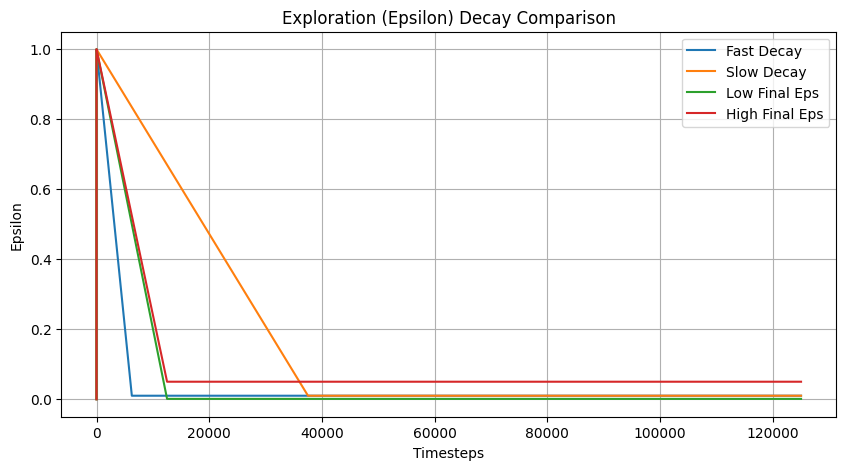

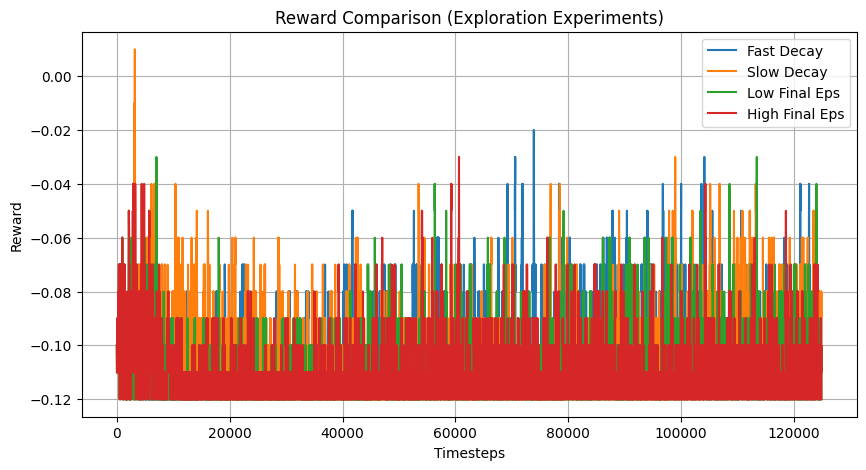

In [4]:
import gymnasium as gym
import ale_py
import numpy as np
import matplotlib.pyplot as plt
import torch

from stable_baselines3 import DQN
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import VecFrameStack
from stable_baselines3.common.callbacks import BaseCallback

gym.register_envs(ale_py)

print("CUDA Available:", torch.cuda.is_available())

# BASE CONFIG
BASE_CONFIG = {
    "policy": "CnnPolicy",
    "learning_rate": 1e-4,
    "buffer_size": 50000,
    "learning_starts": 10000,
    "batch_size": 32,
    "gamma": 0.99,
    "train_freq": 4,
    "gradient_steps": 1,
    "exploration_fraction": 0.1,
    "exploration_final_eps": 0.01,
    "target_update_interval": 1000,
}

# EXPLORATION EXPERIMENTS
EXPERIMENTS = [
    {"name": "Fast Decay", "exploration_fraction": 0.05},
    {"name": "Slow Decay", "exploration_fraction": 0.3},
    {"name": "Low Final Eps", "exploration_final_eps": 0.001},
    {"name": "High Final Eps", "exploration_final_eps": 0.05},
]

# CALLBACK TO TRACK EPSILON + REWARD
class TrackingCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.epsilons = []
        self.rewards = []

    def _on_step(self) -> bool:
        self.epsilons.append(self.model.exploration_rate)

        # reward from env
        if len(self.locals["rewards"]) > 0:
            self.rewards.append(self.locals["rewards"][0])

        return True


# TRAIN FUNCTION
def run_experiment(config, name, timesteps=500000):
    print(f"\nRunning: {name}")

    env = make_atari_env("ALE/Pong-v5", n_envs=4, seed=0)
    env = VecFrameStack(env, n_stack=4)

    model = DQN(
        policy=config["policy"],
        env=env,
        learning_rate=config["learning_rate"],
        buffer_size=config["buffer_size"],
        learning_starts=config["learning_starts"],
        batch_size=config["batch_size"],
        gamma=config["gamma"],
        train_freq=config["train_freq"],
        gradient_steps=config["gradient_steps"],
        exploration_fraction=config["exploration_fraction"],
        exploration_final_eps=config["exploration_final_eps"],
        target_update_interval=config["target_update_interval"],
        device="cuda" if torch.cuda.is_available() else "cpu",
        verbose=1
    )

    callback = TrackingCallback()

    model.learn(total_timesteps=timesteps, callback=callback)

    env.close()

    return callback.epsilons, callback.rewards


# RUN ALL EXPERIMENTS
results = {}

for exp in EXPERIMENTS:
    config = {**BASE_CONFIG, **{k: v for k, v in exp.items() if k != "name"}}
    eps, rew = run_experiment(config, exp["name"])
    results[exp["name"]] = {"epsilon": eps, "reward": rew}


# PLOT EPSILON CURVES
plt.figure(figsize=(10,5))

for name, data in results.items():
    plt.plot(data["epsilon"], label=name)

plt.title("Exploration (Epsilon) Decay Comparison")
plt.xlabel("Timesteps")
plt.ylabel("Epsilon")
plt.legend()
plt.grid()

plt.savefig("epsilon_comparison.png", dpi=300)
plt.show()


# PLOT REWARD CURVES
plt.figure(figsize=(10,5))

for name, data in results.items():
    rewards = np.array(data["reward"])

    # Smooth curve
    if len(rewards) > 100:
        smooth = np.convolve(rewards, np.ones(100)/100, mode='valid')
    else:
        smooth = rewards

    plt.plot(smooth, label=name)

plt.title("Reward Comparison (Exploration Experiments)")
plt.xlabel("Timesteps")
plt.ylabel("Reward")
plt.legend()
plt.grid()

plt.savefig("reward_comparison.png", dpi=300)
plt.show()